# Decision Tree Classification on NHANES 2021–2023
## Socioeconomic Determinants of Health Insurance Coverage

This notebook builds a **Decision Tree classifier** to predict **health insurance type** 
based on socioeconomic variables using the cleaned NHANES 2021–2023 dataset.

We focus on:

1. Data loading and preprocessing (age ≥ 18).
2. Building a Decision Tree to predict `insurance_type`.
3. Evaluating model performance (Accuracy, Precision, Recall, F1, ROC-AUC).
4. Visualizing the decision tree and feature importance.
5. Connecting results to the association rules (FP-growth) analysis.


In [30]:
# Basic utilities
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# 保存图片的文件夹路径（根据你的文件结构写）
FIG_DIR = "../reports/figures"

# 没有文件夹就创建
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    filepath = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(filepath, dpi=300, bbox_inches="tight")

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.preprocessing import LabelEncoder


In [31]:
# Load cleaned NHANES dataset
# Make sure nhanes_clean.csv is in the same folder as this notebook
df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean.csv")

print("Shape of raw cleaned dataset:", df.shape)
df.head()


Shape of raw cleaned dataset: (11933, 21)


,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,a1c,glucose,smoking_current,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,5.6,113.0,Yes,Unknown,45.0,9.5,No,Insured,Yes,Private only
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,5.6,99.0,Yes,Unknown,45.0,9.0,No,Insured,Unknown,Both
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,6.2,156.0,No,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only
3,130381.0,5.0,Female,Other Race / Multi,Unknown,1.53,34.3,120.1,23.8,117.0,...,5.5,100.0,Unknown,Unknown,45.0,8.0,No,Insured,Yes,Public only
4,130382.0,2.0,Male,Non-Hispanic White,Unknown,3.60,13.6,105.0,16.3,117.0,...,5.5,100.0,Unknown,Unknown,45.0,8.0,No,Insured,Unknown,Private only


In [32]:
# Keep adults (age >= 18), consistent with FP-mining step
df_adult = df[df["age"] >= 18].copy()
print("Shape after filtering adults (age >= 18):", df_adult.shape)

# Check missing values for key variables
cols_of_interest = ["age", "gender", "race", "education",
                    "income_poverty_ratio", "insurance_type"]

df_adult[cols_of_interest].isna().sum()


Shape after filtering adults (age >= 18): (8153, 21)


age                     0
gender                  0
race                    0
education               0
income_poverty_ratio    0
insurance_type          0
dtype: int64

In [33]:
# Drop rows with missing values in key columns
dt_data = df_adult[cols_of_interest].dropna().copy()
print("Shape after dropping NA in key columns:", dt_data.shape)

# Define features (X) and target (y)
feature_cols = ["age", "gender", "race", "education", "income_poverty_ratio"]
target_col = "insurance_type"

X = dt_data[feature_cols].copy()
y = dt_data[target_col].copy()


Shape after dropping NA in key columns: (8153, 6)


In [34]:
# Identify categorical features
categorical_cols = ["gender", "race", "education"]
label_encoders = {}

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target variable (insurance_type)
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y.astype(str))

print("Encoded classes for insurance_type:", target_encoder.classes_)


Encoded classes for insurance_type: ['Both' 'Private only' 'Public only' 'Uninsured' 'Unknown']


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded  # 保持各类比例一致
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (6522, 5) Test size: (1631, 5)


In [36]:
# 定义一个基础的 Decision Tree 模型（和之后 final 模型保持一致）
dt_cv = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

# 在 training set 上做 10-fold CV
cv_scores = cross_val_score(
    dt_cv, 
    X_train, 
    y_train, 
    cv=10, 
    scoring="accuracy"
)

print("Decision Tree 10-fold CV Accuracy:")
print("Scores for each fold:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

Decision Tree 10-fold CV Accuracy:
Scores for each fold: [0.59877489 0.61715161 0.61503067 0.60889571 0.60122699 0.60276074
 0.62269939 0.59815951 0.61349693 0.58128834]
Mean CV accuracy: 0.6059484775317319
Std CV accuracy: 0.011432232862151911


In [37]:
dt = DecisionTreeClassifier(
    criterion="gini",      # 计算效率高，和 entropy 效果差不多
    max_depth=5,           # 树不太深，Graphviz 画出来还能看清楚路径
    min_samples_split=50,  # 每个内部节点至少 50 人，再往下分
    min_samples_leaf=20,   # 每个叶子至少 20 人，避免特别小的叶子
    class_weight=None,     # 主模型不做 class 平衡，追求稳定整体表现
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

In [38]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.6088289393010423
              precision    recall  f1-score   support

        Both       0.55      0.33      0.41       257
Private only       0.66      0.88      0.75       584
 Public only       0.57      0.61      0.59       625
   Uninsured       0.50      0.11      0.18       141
     Unknown       0.00      0.00      0.00        24

    accuracy                           0.61      1631
   macro avg       0.46      0.38      0.39      1631
weighted avg       0.58      0.61      0.58      1631



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x600 with 0 Axes>

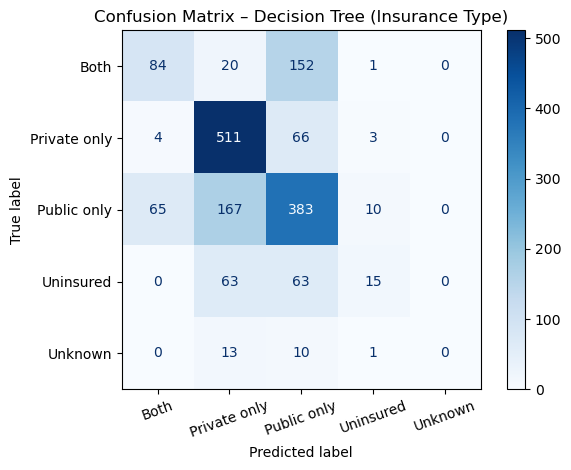

In [39]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Decision Tree (Insurance Type)")
plt.xticks(rotation=20)
plt.tight_layout()
save_fig(fig, "dt_confusion_matrix_insurance") 
plt.show()


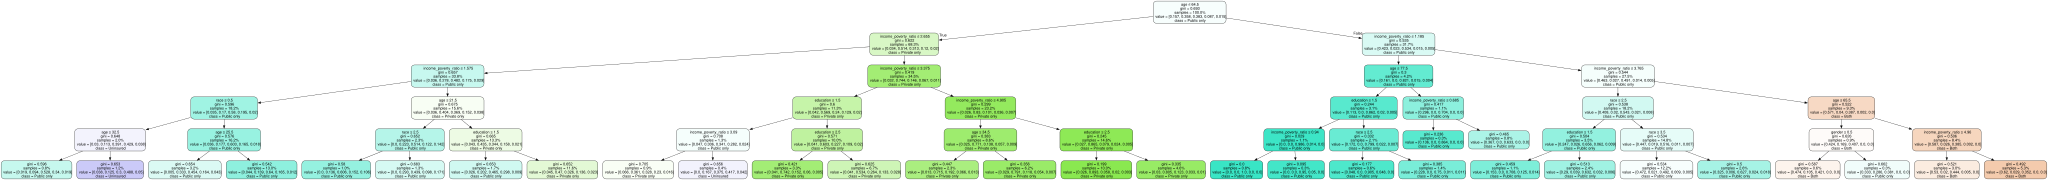

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt,                                  
    out_file=None,
    feature_names=X.columns,              # ["age", "gender", "race", "education", "income_poverty_ratio"]
    class_names=target_encoder.classes_,  # ['Both', 'Private only', ...]
    filled=True,                          
    rounded=True,                         
    proportion=True,                      
    special_characters=True
)

graph = graphviz.Source(dot_data)
display(graph)
graph.render(
    filename="dt_full_tree",
    directory=FIG_DIR,
    format="png",
    cleanup=True
)
print("Saved full decision tree to:", os.path.join(FIG_DIR, "dt_full_tree.png"))

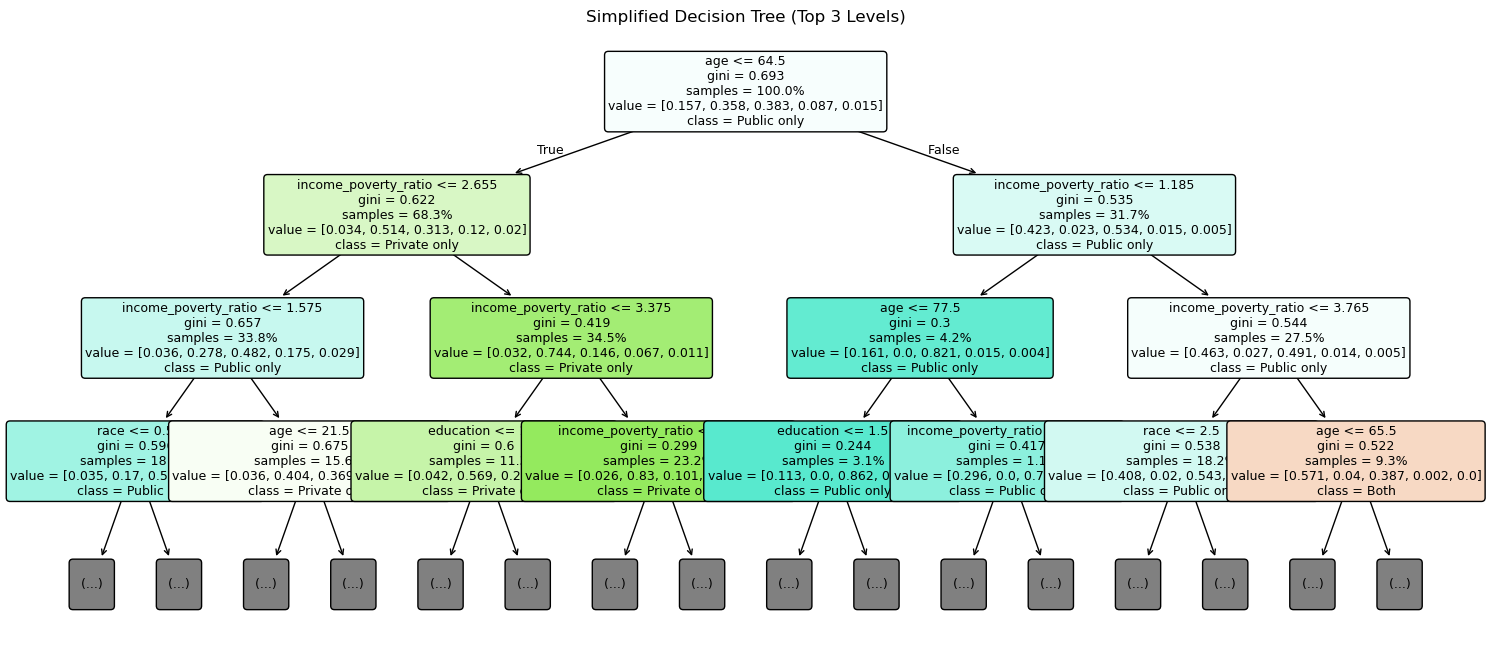

In [40]:
from sklearn import tree
fig = plt.figure(figsize=(18, 8))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,       
    proportion=True,
    fontsize=9
)
plt.title("Simplified Decision Tree (Top 3 Levels)")
save_fig(fig, "dt_tree_top3_levels") 
plt.show()


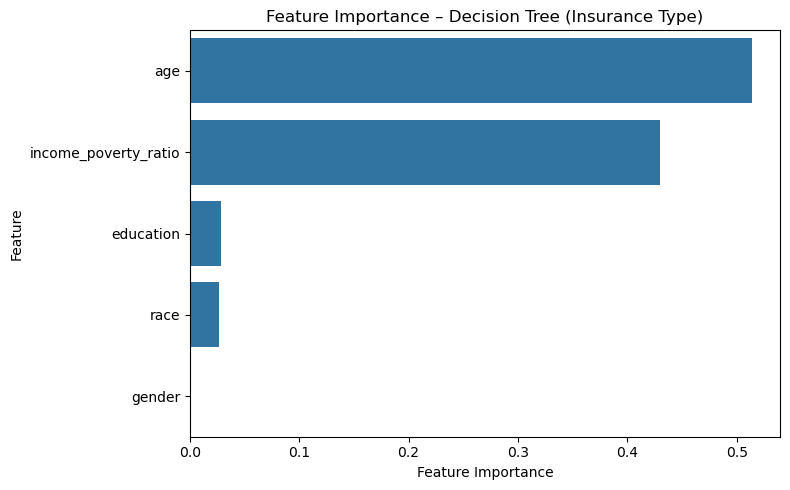

age                     0.513905
income_poverty_ratio    0.430068
education               0.028765
race                    0.026705
gender                  0.000556
dtype: float64

In [41]:
import seaborn as sns

importances = dt.feature_importances_
feature_cols = ["age", "gender", "race", "education", "income_poverty_ratio"]

feat_imp = (
    pd.Series(importances, index=feature_cols)
    .sort_values(ascending=False)
)

fig = plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance – Decision Tree (Insurance Type)")
save_fig(fig, "dt_feature_importance") 
plt.tight_layout()
plt.show()

feat_imp
